# Hệ thống Phát hiện Fake News sử dụng Knowledge Verification

## Thành viên:
* Huỳnh Anh Nhựt (Nhóm trưởng)
* Nguyễn Tiến Minh
* Huỳnh Anh Tuấn

## 1. Sử dụng Dataset từ FakeNewsNet

### Gossicop (Tin giải trí)

In [4]:
import pandas as pd
import numpy as np

goosicop_fake_news = pd.read_csv('data/raw/gossipcop_fake.csv')

goosicop_fake_news.head()

,id,news_url,title,tweet_ids
0,gossipcop-2493749932,www.dailymail.co.uk/tvshowbiz/article-5874213/...,Did Miley Cyrus and Liam Hemsworth secretly ge...,284329075902926848\t284332744559968256\t284335...
1,gossipcop-4580247171,hollywoodlife.com/2018/05/05/paris-jackson-car...,Paris Jackson & Cara Delevingne Enjoy Night Ou...,992895508267130880\t992897935418503169\t992899...
2,gossipcop-941805037,variety.com/2017/biz/news/tax-march-donald-tru...,Celebrities Join Tax March in Protest of Donal...,853359353532829696\t853359576543920128\t853359...
3,gossipcop-2547891536,www.dailymail.co.uk/femail/article-3499192/Do-...,Cindy Crawford's daughter Kaia Gerber wears a ...,988821905196158981\t988824206556172288\t988825...
4,gossipcop-5476631226,variety.com/2018/film/news/list-2018-oscar-nom...,Full List of 2018 Oscar Nominations – Variety,955792793632432131\t955795063925301249\t955798...


In [5]:
gossipcop_real_news = pd.read_csv('data/raw/gossipcop_real.csv')

gossipcop_real_news.head()

,id,news_url,title,tweet_ids
0,gossipcop-882573,https://www.brides.com/story/teen-mom-jenelle-...,Teen Mom Star Jenelle Evans' Wedding Dress Is ...,912371411146149888\t912371528343408641\t912372...
1,gossipcop-875924,https://www.dailymail.co.uk/tvshowbiz/article-...,Kylie Jenner refusing to discuss Tyga on Life ...,901989917546426369\t901989992074969089\t901990...
2,gossipcop-894416,https://en.wikipedia.org/wiki/Quinn_Perkins,Quinn Perkins,931263637246881792\t931265332022579201\t931265...
3,gossipcop-857248,https://www.refinery29.com/en-us/2018/03/19192...,I Tried Kim Kardashian's Butt Workout & Am For...,868114761723936769\t868122567910936576\t868128...
4,gossipcop-884684,https://www.cnn.com/2017/10/04/entertainment/c...,Celine Dion donates concert proceeds to Vegas ...,915528047004209152\t915529285171122176\t915530...


### Politifact (Tin chính trị)

In [6]:
politiifact_fake_news = pd.read_csv('data/raw/politifact_fake.csv')

politiifact_fake_news.head()

,id,news_url,title,tweet_ids
0,politifact15014,speedtalk.com/forum/viewtopic.php?t=51650,BREAKING: First NFL Team Declares Bankruptcy O...,937349434668498944\t937379378006282240\t937380...
1,politifact15156,politics2020.info/index.php/2018/03/13/court-o...,Court Orders Obama To Pay $400 Million In Rest...,972666281441878016\t972678396575559680\t972827...
2,politifact14745,www.nscdscamps.org/blog/category/parenting/467...,UPDATE: Second Roy Moore Accuser Works For Mic...,929405740732870656\t929439450400264192\t929439...
3,politifact14355,https://howafrica.com/oscar-pistorius-attempts...,Oscar Pistorius Attempts To Commit Suicide,886941526458347521\t887011300278194176\t887023...
4,politifact15371,http://washingtonsources.org/trump-votes-for-d...,Trump Votes For Death Penalty For Being Gay,915205698212040704\t915242076681506816\t915249...


In [7]:
politiifact_real_news = pd.read_csv('data/raw/politifact_real.csv')

politiifact_real_news.head()

,id,news_url,title,tweet_ids
0,politifact14984,http://www.nfib-sbet.org/,National Federation of Independent Business,967132259869487105\t967164368768196609\t967215...
1,politifact12944,http://www.cq.com/doc/newsmakertranscripts-494...,comments in Fayetteville NC,942953459\t8980098198\t16253717352\t1668513250...
2,politifact333,https://web.archive.org/web/20080204072132/htt...,"Romney makes pitch, hoping to close deal : Ele...",NaN
3,politifact4358,https://web.archive.org/web/20110811143753/htt...,Democratic Leaders Say House Democrats Are Uni...,NaN
4,politifact779,https://web.archive.org/web/20070820164107/htt...,"Budget of the United States Government, FY 2008",89804710374154240\t91270460595109888\t96039619...


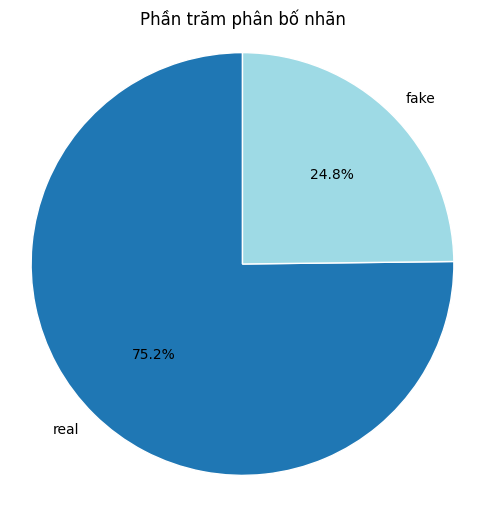

In [10]:
import matplotlib.pyplot as plt

df_processed = pd.read_csv('data/processed/processed_fakenews_data.csv')

def plot_label_pie(df, label_col='label', title='Label distribution', autopct='%1.1f%%', cmap='tab20', figsize=(6,6), savepath=None):
    counts = df[label_col].value_counts()
    labels = counts.index.astype(str)
    sizes = counts.values
    colors = plt.get_cmap(cmap)(np.linspace(0, 1, len(labels)))
    fig, ax = plt.subplots(figsize=figsize)
    ax.pie(sizes, labels=labels, autopct=autopct, startangle=90, colors=colors, wedgeprops=dict(edgecolor='w'))
    ax.axis('equal')
    ax.set_title(title)
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()

plot_label_pie(df_processed, label_col='label', title='Phần trăm phân bố nhãn', savepath='data/processed/label_distribution_pie.png')


C:\Users\MSI VN\AppData\Local\Temp\ipykernel_8684\2332299309.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


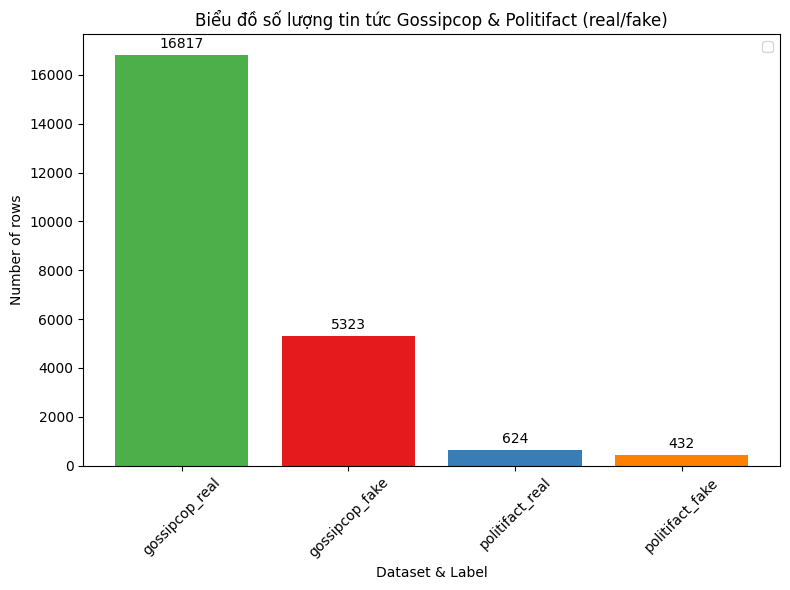

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load raw datasets
gossip_fake = pd.read_csv('data/raw/gossipcop_fake.csv')
gossip_real = pd.read_csv('data/raw/gossipcop_real.csv')
politifact_fake = pd.read_csv('data/raw/politifact_fake.csv')
politifact_real = pd.read_csv('data/raw/politifact_real.csv')

# Counts per dataset/label
counts = {
    'gossipcop_real': len(gossip_real),
    'gossipcop_fake': len(gossip_fake),
    'politifact_real': len(politifact_real),
    'politifact_fake': len(politifact_fake),
}
labels = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(8,6))
bars = plt.bar(labels, values, color=['#4daf4a','#e41a1c','#377eb8','#ff7f00'])
plt.xlabel('Dataset & Label')
plt.ylabel('Number of rows')
plt.title('Biểu đồ số lượng tin tức Gossipcop & Politifact (real/fake)')
plt.xticks(rotation=45)
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+max(values)*0.01, f'{int(y)}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('data/processed/dataset_label_counts.png', bbox_inches='tight')
plt.legend(['Gossipcop Real', 'Gossipcop Fake', 'Politifact Real', 'Politifact Fake'])
plt.show()


## 2. Tiền xử lý dữ liệu FakeNewsNet (Preprocessing)

### Dữ liệu chưa qua xử lý

In [ ]:
df_news = pd.concat([goosicop_fake_news, gossipcop_real_news, politiifact_fake_news, politiifact_real_news], ignore_index=True)

,id,news_url,title,tweet_ids
0,gossipcop-2493749932,www.dailymail.co.uk/tvshowbiz/article-5874213/...,Did Miley Cyrus and Liam Hemsworth secretly ge...,284329075902926848\t284332744559968256\t284335...
1,gossipcop-4580247171,hollywoodlife.com/2018/05/05/paris-jackson-car...,Paris Jackson & Cara Delevingne Enjoy Night Ou...,992895508267130880\t992897935418503169\t992899...
2,gossipcop-941805037,variety.com/2017/biz/news/tax-march-donald-tru...,Celebrities Join Tax March in Protest of Donal...,853359353532829696\t853359576543920128\t853359...
3,gossipcop-2547891536,www.dailymail.co.uk/femail/article-3499192/Do-...,Cindy Crawford's daughter Kaia Gerber wears a ...,988821905196158981\t988824206556172288\t988825...
4,gossipcop-5476631226,variety.com/2018/film/news/list-2018-oscar-nom...,Full List of 2018 Oscar Nominations – Variety,955792793632432131\t955795063925301249\t955798...
5,gossipcop-5189580095,www.townandcountrymag.com/society/tradition/a1...,Here's What Really Happened When JFK Jr. Met P...,890253005299351552\t890401381814870016\t890491...
6,gossipcop-9588339534,www.foxnews.com/entertainment/2016/12/16/bigge...,Biggest celebrity scandals of 2016,683226380742557696\t748604615503929345\t748604...
7,gossipcop-8753274298,www.eonline.com/news/958257/caitlyn-jenner-add...,Caitlyn Jenner Addresses Rumored Romance With ...,1026891446081728512\t1026891745219543043\t1026...
8,gossipcop-8105333868,www.inquisitr.com/3871816/taylor-swift-reporte...,Taylor Swift Reportedly Reacts To Tom Hiddlest...,818928533569437697\t819100640878202880\t819174...
9,gossipcop-2803748870,www.huffingtonpost.com/entry/kate-mckinnon-the...,"For The Love Of God, Why Can't Anyone Write Ka...",816030248190046212\t816030859484626947\t816049...


### Dữ liệu đã xử lý

In [3]:
df_news = pd.read_csv('data/processed/processed_fakenews_data.csv')

df_news.head(5)

,2id,claim,entities,label,source
0,gossipcop-2493749932,Did Miley Cyrus and Liam Hemsworth secretly ge...,"['Miley Cyrus', 'Liam Hemsworth']",fake,gossipcop
1,gossipcop-4580247171,Paris Jackson & Cara Delevingne Enjoy Night Ou...,['Paris Jackson & Cara Delevingne'],fake,gossipcop
2,gossipcop-941805037,Celebrities Join Tax March in Protest of Donal...,['Donald Trump'],fake,gossipcop
3,gossipcop-2547891536,Cindy Crawford's daughter Kaia Gerber wears a ...,"[""Cindy Crawford's"", 'Harry Styles', 'Kaia Ger...",fake,gossipcop
4,gossipcop-5476631226,Full List of 2018 Oscar Nominations – Variety,['Oscar Nominations'],fake,gossipcop


In [5]:
df_evidence = pd.read_csv('data/processed/evidence_retrieved_live.csv')

df_evidence.head(5)

,2id,claim,entities,label,source,evidence
0,gossipcop-2493749932,Did Miley Cyrus and Liam Hemsworth secretly ge...,"['Miley Cyrus', 'Liam Hemsworth']",fake,gossipcop,Against the advice of her father's record comp...
1,gossipcop-4580247171,Paris Jackson & Cara Delevingne Enjoy Night Ou...,"['Cara Delevingne', 'Paris Jackson']",fake,gossipcop,"In February 2015, Delevingne appeared in ASAP ..."
2,gossipcop-941805037,Celebrities Join Tax March in Protest of Donal...,['Donald Trump'],fake,gossipcop,"Donald John Trump (born June 14, 1946) is an A..."
3,gossipcop-2547891536,Cindy Crawford's daughter Kaia Gerber wears a ...,"[""Cindy Crawford's"", 'Kaia Gerber', 'Harry Sty...",fake,gossipcop,She is the second child and only daughter of t...
4,gossipcop-5476631226,Full List of 2018 Oscar Nominations – Variety,['Oscar Nominations'],fake,gossipcop,"Beginning with the second ceremony, performers..."


### Baseline model(Logistic Regression + TF IDF)

In [3]:
from baseline import train_baseline, evaluate_baseline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model, vectorizer = train_baseline()

baseline_metrics = evaluate_baseline(model, vectorizer)

print("Baseline Metrics:")

baseline_metrics 


Baseline Metrics:


{'accuracy': 0.8146551724137931,
 'precision': 0.8021320432229374,
 'recall': 0.8146551724137931,
 'f1': 0.7921583434574813,
 'confusion_matrix': [[1680, 82], [348, 210]]}